# Signal Analysis and Preprocessing

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Explore the wide range of neurotechnological applications that make use of neural oscillations
- Understand the difference between evoked responses (e.g. ERPs) and induced responses (e.g. oscillations)
- Get familiar with important signal analysis and (pre-)processing concepts like sampling frequency, Nyquist frequency, aliasing, detrending, spectral filtering, convolution, Hilbert transform, FFT, and spectrogram. 

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


# Exercise 1: Neurotechnology

Make a forum post about a neurotechnology application that uses oscillatory signals. Find an interesting neurotechnological application that uses neural oscillations (as opposed to evoked responses). Ideas about directions to search for are neuro- or motor-rehabilitation (e.g., the alpha/mu and beta rhythms), neurofeedback (e.g., the alpha and theta rhythms), or sleep studies (e.g., alpha, slow-wave sleep, deep sleep).
1. Find an interesting application of neurotechnology, post a link to it (e.g., the blog post, article, podcast, video, etc.) in the assignment forum of Week 08. Describe the application in a few sentences. As the subject of your posts, use a sensible title that explains the body. 
1. We encourage to comment on each other's posts and to answer each other's questions. Comment on at least one of the applications of other groups with interesting additional information or a critical question.


# Exercise 2: Setting up the data

We'll be looking at some EEG data related to an eyes open and eyes closed paradigm, to get familiar with certain pre-processing and datahandling concepts. 

1. Download the data from Brightspace
1. Load the data with the provided functions

In [2]:
import os
import mne
import scipy.fft as fft #для преобразования Фурье (анализ частот)
from scipy.signal import spectrogram, chirp, hilbert, butter, sosfilt, detrend #различные функции для обработки сигналов
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

np.random.seed(42)

* EOGvu - электроокулограмма (движения глаз)
* x_EMGl - электромиограмма (мышечная активность)
* x_GSR - кожно-гальваническая реакция
* x_Respi - дыхание
* x_Pulse - пульс
* x_Optic - оптический сигнал (метка)

Почему именно электрод Oz?  
   * Затылочная область мозга наиболее чувствительна к зрительной активности  
   * При закрытии глаз в этой области обычно наблюдается усиление альфа-ритма (8-13 Гц)  
   * Это классический парадигм для изучения альфа-активности  
    
На графике будут видны два сигнала, где можно ожидать, что сигнал с закрытыми глазами будет иметь более выраженные периодические колебания (альфа-ритм) по сравнению с сигналом с открытыми глазами.  
Роль альфа-ритма (8-13 Гц)   
Альфа-ритм - это ритм покоя зрительной системы. Он генерируется в таламо-кортикальных сетях, когда:
* Закрыты глаза - зрительная система не обрабатывает внешнюю информацию
* Расслабленное состояние - человек не выполняет зрительные задачи


        rhythm_locations = {
            'alpha': ['O1', 'O2', 'Oz', 'Pz'],  # ЗАТЫЛОЧНЫЕ и ТЕМЕННЫЕ области
            'beta':  ['C3', 'C4', 'Cz'],        # ЦЕНТРАЛЬНЫЕ (моторная кора)
            'theta': ['Fz', 'F3', 'F4'],        # ЛОБНЫЕ области
            'delta': ['Fp1', 'Fp2']             # ПРЕФРОНТАЛЬНЫЕ
        }

Text(0.5, 1.0, 'EEG Data collected from electrode Oz')

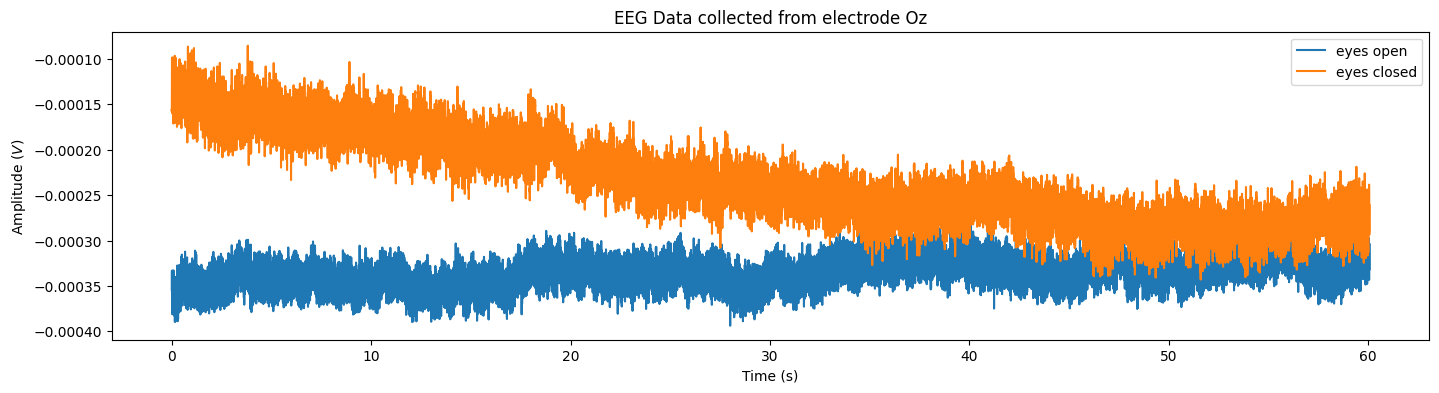

In [3]:
def load_and_preprocess_raw(header_file):
    non_eeg_channels = ["EOGvu", "x_EMGl", "x_GSR", "x_Respi", "x_Pulse", "x_Optic"]
    raw = mne.io.read_raw_brainvision(header_file, misc=non_eeg_channels, preload=True) #загрузка данных(.vhdr, .eeg, .vmrk); misc каналы =вспомогательныe
    # preload=True - сразу загружает данные в оперативную память (иначе работает "ленивая" загрузка)
    raw.set_montage("standard_1020") # Устанавливает стандартную схему расположения электродов 10-20
    raw.pick_types(eeg=True) #Оставляет только EEG-каналы и удаляет все остальные (включая указанные в misc)
    return raw

# Load data
eyes_open = load_and_preprocess_raw(os.path.join(os.getcwd(), "data", "eyes_open.vhdr")) # Загружаются два набора данных: с открытыми и закрытыми глазами
eyes_closed = load_and_preprocess_raw(os.path.join(os.getcwd(), "data", "eyes_close.vhdr"))

# Visualize data
plt.figure(figsize=(17, 4))
plt.plot(eyes_open.times, eyes_open["Oz"][0].flatten(), label='eyes open') #(времен шкал в сек для данных открытглаз,  Oz.1ый эл.в 1д,   )
plt.plot(eyes_closed.times, eyes_closed["Oz"][0].flatten(), label='eyes closed')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude ($V$)')
plt.title('EEG Data collected from electrode Oz')


# Exercise 3: Detrending the data

As you can see above, the data may sometimes exhibit a (linear) trend. In such cases it might be useful to (linearly) detrend the data. Fortunately, that is an easy thing to do, using the `detrend()` function from the `scipy.signal` library.
1. Detrend the data (a single channel and epoch is enough)
1. Plot the detrended data
1. What are potential reasons for trends in the data? Name at least 3 possible reasons
1. Explain in your own words what (linear) detrending does.

* Улучшение анализа: Тренд мешает спектральному анализу и корреляции
* Визуализация: Лучше видно колебания сигнала
* Статистика: Устраняет систематическое смещение

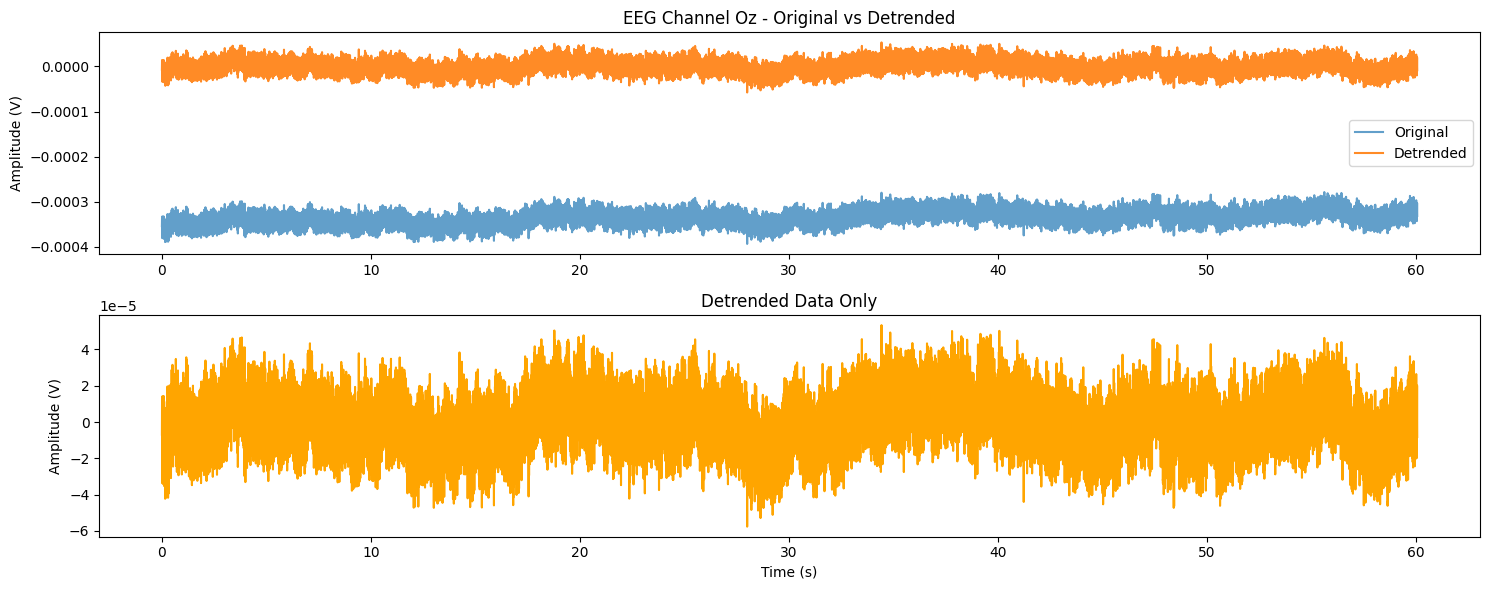

In [4]:
# Детрендинг данных
oz_open_original = eyes_open["Oz"][0].flatten()
oz_open_detrended = detrend(oz_open_original)

# Визуализация результатов
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(eyes_open.times, oz_open_original, label='Original', alpha=0.7)
plt.plot(eyes_open.times, oz_open_detrended, label='Detrended', alpha=0.9)
plt.legend()
plt.title('EEG Channel Oz - Original vs Detrended')
plt.ylabel('Amplitude (V)')

plt.subplot(2, 1, 2)
plt.plot(eyes_open.times, oz_open_detrended, color='orange')
plt.title('Detrended Data Only')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')

plt.tight_layout()
plt.show()

1. Возможные причины тренда в данных:
* Дрейф постоянного напряжения в усилителях ЭЭГ
* Потоотделение под электродами меняет импеданс
* Дыхание и движения тела создают медленные артефакты
* Термоэлектрические эффекты на границе электрод-кожа
* Изменение кровотока в коже головы
* Высыхание геля электродов
* Температурные колебания окружающей среды

2. Что делает линейный детрендинг:  
Детрендинг находит и вычитает линейную составляющую из сигнала. Представьте, что ваш сигнал = (прямая линия + настоящие колебания). Функция detrend() убирает эту прямую линию, оставляя только колебания вокруг нуля.  
  
Результат: После детрендинга сигнал становится "центрированным" вокруг нуля, что улучшает последующий спектральный анализ и визуализацию.

Линейное удаление тренда - это процесс, который:  
    🎯 Убирает медленные линейные изменения сигнала  
    💡 Сохраняет все быстрые нейронные колебания (альфа, бета, тета ритмы)  
    📊 Центрирует сигнал вокруг нуля для лучшего анализа  
    🔧 Устраняет технические артефакты, не связанные с мозговой активностью  

# (Optional) Exercise 4: Convolution

Though we aren't making explicit use of it in this assignment, you should be familiar with the mathematical operation *convolution*. Check out these resources for a refresher:
* [Convolution on Wikipedia](https://en.wikipedia.org/wiki/Convolution)
* [Mike Cohen's great YouTube video on convolution](https://youtu.be/9Hk-RAIzOaw)

1. Explain in your own words what convolution is.

Answer here
Что такое свертка?

Свертка - это математический способ измерить "похожесть" двух сигналов в каждый момент времени. -это математическая операция, которая показывает, как одна функция "размазывается" по другой.  

Представьте, что вы:
* Ищете определенный рисунок на большом ковре
* Накладываете маленький шаблон на разные участки ковра
* Смотрите, насколько хорошо шаблон совпадает с рисунком в каждом месте
* Представьте, что вы наносите краску кистью на холст. Кисть — это один сигнал (ядро), холст — другой. Свёртка показывает, как именно распределится краска.
  
Формула: выход[n] = ∑ вход[k] × ядро[n-k]
  
В ЭЭГ: Когда сигнал проходит через фильтр — это и есть свёртка сигнала с импульсной характеристикой фильтра.

    def convolution(signal, filter):
        результат = []
        for каждый_момент_времени:
            # 1. "Прикладываем" фильтр к сигналу
            # 2. Умножаем совпадающие точки  
            # 3. Суммируем результаты
            # 4. Получаем меру сходства в этой точке
        return результат

"Насколько сигнал здесь и сейчас похож на наш фильтр/шаблон?"  
Зачем это в нейронауке:  
🧠 Обнаружение ритмов - ищем альфа-ритм в EEG сигнале  
🔍 Выделение паттернов - находим специфические формы волн  
📊 Анализ ответов - изучаем, как мозг реагирует на стимулы  

Свертка - это как "умная лупа", которая ищет определенные узоры в данных! 🔎✨  

https://upload.wikimedia.org/wikipedia/commons/thumb/2/21/Comparison_convolution_correlation.svg/500px-Comparison_convolution_correlation.svg.png
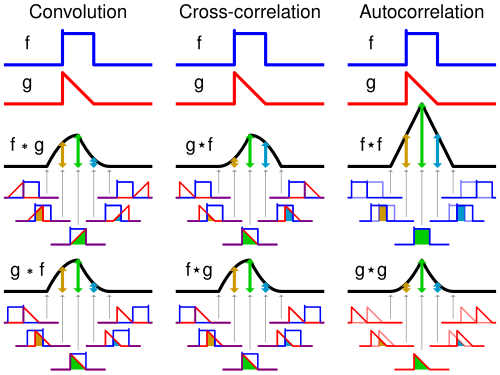
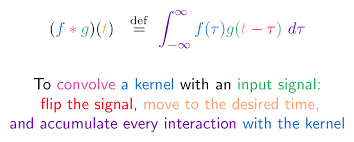
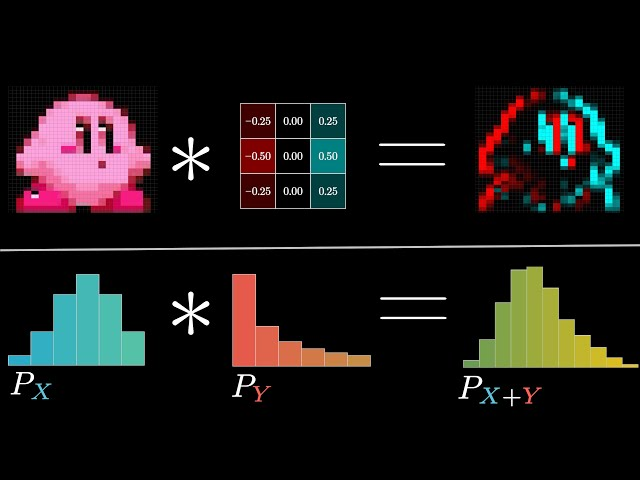


# Exercise 5: Sampling rate and the Shannon-Nyquist Theorem.

Back in Applied Mathematics you were introduced to the basics of signal analysis. An important concept is the sampling frequency. Firstly, it is required that you understand the [Shannon-Nyquist sampling theorem](https://home.strw.leidenuniv.nl/~por/AOT2019/docs/AOT_2019_Ex13_NyquistTheorem.pdf).

In a few words, explain:
1. What sampling frequency means and what is the sampling frequency of the data in this assignment;
1. What the Nyquist frequency entails and what is the specific value for our data;
1. What aliasing is and what the frequency range in our data is where we might be experiencing aliasing;
1. How to prevent aliasing.

Answer here  

1) sampling frequency   
 Что это: Сколько раз в секунду мы измеряем сигнал  
 В наших данных: 1000 Гц (стандарт для ЭЭГ)  
 Значит: Каждую 1/1000 секунды записывается новое значение  

2. Nyquist frequency   
 Формула: f_nyquist = f_sample / 2  
 В наших данных: 500 Гц  
 Что это: Максимальная частота, которую можно корректно восстановить  

3. aliasing     
 Что это: Эффект, когда высокие частоты "маскируются" под низкие  
 Возникает: Когда в сигнале есть частоты ВЫШЕ 500 Гц  
 Пример: Сигнал 600 Гц будет выглядеть как 400 Гц   (1000(изначально снимали) - 600(сигнал выше 500) = 400(будет выглядеть как))  

4. Как предотвратить:
* Антиалиасинговый фильтр: Фильтр низких частот перед записью
* Обрезает все частоты выше частоты Найквиста (пропускает только чатоты 0-500Гц)  
* В ЭЭГ-оборудовании это делается автоматически
  
Для наших данных: Мы можем анализировать частоты до 500 Гц, но реально ЭЭГ полезен до ~80 Гц, поэтому алиасинг маловероятен.
  

In [5]:
# Answer here

# retrieve the sampling frequency
print("Info for Eyes Open:\n", eyes_open.info)
print("\nInfo for Eyes Closed:\n")
eyes_closed.info

Info for Eyes Open:
 <Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: 2015-09-15 10:11:42 UTC
 nchan: 63
 projs: []
 sfreq: 1000.0 Hz
>

Info for Eyes Closed:



<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: 2015-09-15 10:13:19 UTC
 nchan: 63
 projs: []
 sfreq: 1000.0 Hz
>

# Exercise 6: Spectral analysis

We can analyze the frequency contents of a signal, that is - the frequencies that make up the signal, by computing its frequency spectrum. One of the most common ways to do that is by using the Fast Fourier Transform (FFT), that you have learned about in Applied Mathematics. If you need a refresher here is a nice [video about it](https://youtu.be/spUNpyF58BY). For additional appreciation of the beauty behind the Fourier series we also recommend [this other video](https://youtu.be/r6sGWTCMz2k).

1. Use the numpy or scipy functions `rfft` and `rfftfreq` (the scipy implementation is built on top of numpy so these are equivalent) to obtain the frequency response and frequency range of the `eyes_open` data. Then, plot them to observe the frequency spectrum. It is up to you which channel you want to work with.
2. Observe that there is a large peak at around 50Hz. Can you explain what caused this peak? **Tip**: it's not because of the participant's brain.
3. How can we remove this frequency component? **Tip**: if you can't think of a solution, finish the notebook and come back to this question later.
4. Note that we also need a sufficient amount of data points to obtain a nice frequency resolution. This can be demonstrated by running the FFT on a tiny time window from our data. Do this by running the procedure from the first subexercise on a tiny portion (equal to a 16th) of the data. Compare the newly obtained spectrum to the original one. You should be able to see spectral leakage happening in the frequency spectrum obtained from less samples (e.g. easily apparent at the 50Hz spike) **Tip**: if you can't see the difference immediately, try zooming in on the first 60 frequencies.

We've provided you with 2 recordings - one where the participant had their eyes open (`eyes_open` variable) and one with their eyes were closed (`eyes_closed` variable). 

5. What difference do you expect to see in the spectral content of the 2 recordings?
6. Plot the frequency spectrum of a single channel for each of the two conditions. Is the answer you gave to the previous question in line with what you see? **Tip:** carefully think about which channel to visualize!

The frequency spectrum we plotted shows how much each frequency contributes to the entirity of the signal. However it is not the case that at each **time point** their contribution was equal. In order to capture spectro-temporal characteristic, we may want to instead compute the spectrogram. A spectro-gram is a time-frequency representation (TFR) that, as the name suggests, gives us information about the frequency spectrum at different time points.

7. Use the `spectrogram` function, provided by the `scipy.signal` library to easily compute the spectrogram of the whole signal. Do this for the eyes closed condition. 
8. Plot the spectrogram. What do you observe?


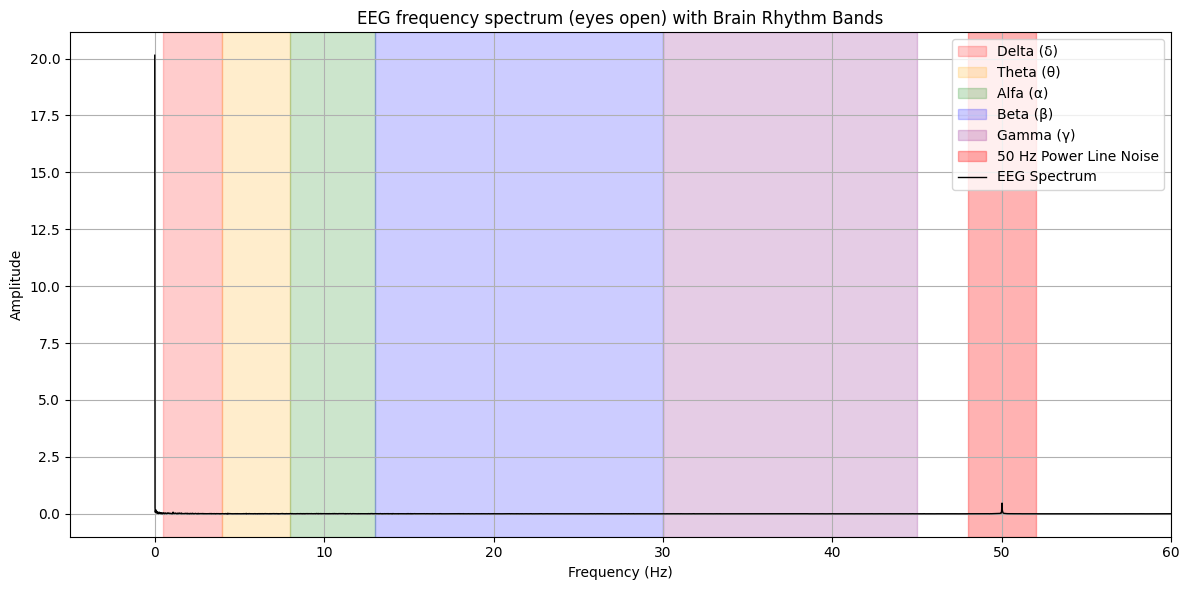

ЧТО МЫ СДЕЛАЛИ:
1. rfft - преобразовали временной сигнал в частотную область
2. rfftfreq - получили частотную шкалу для графика
3. Построили спектр - визуализацию мощности на разных частотах
4. Частота дискретизации: 1000.0 Гц
5. Максимальная анализируемая частота: 500.0 Гц


In [6]:
# Answer here 1
# Предположим, что у нас есть данные EEG
# eyes_open - массив с временными рядами ЭЭГ сигнала
# sampling_rate - частота дискретизации (например, 250 Гц)

""" 
rfft
Вычисляет быстрое преобразование Фурье для действительных (не комплексных) сигналов
Возвращает только положительные частоты (от 0 до частоты Найквиста)
Превращает сигнал из временной области в частотную

rfftfreq
Создает массив частот для результатов rfft
n - длина исходного сигнала
d - интервал дискретизации (1/частота_дискретизации)   интервал между измерениями
Возвращает: Массив частот от 0 до частоты Найквиста
"""
oz_open_original = eyes_open["Oz"][0].flatten()
#oz_open_detrended = detrend(oz_open_original)
sampling_rate = eyes_open.info['sfreq']  

# rfft - БПФ для действительных сигналов (возвращает только положительные частоты)
#rfft - FFT for valid signals (returns only positive frequencies)
rfft_result = fft.rfft(oz_open_original)

# Вычисляем амплитудный спектр (модуль комплексных чисел)
# Calculate the amplitude spectrum
amplitude_spectrum = np.abs(rfft_result)

# Получаем соответствующие частоты
# Get the corresponding frequencies
frequencies = fft.rfftfreq(len(oz_open_original), 1/sampling_rate)

# Показываем основные EEG ритмы  --Обозначает стандартные частотные диапазоны мозговой активности
eeg_bands = {
    'Delta (δ)': (0.5, 4),    # Глубокий сон, медитация
    'Theta (θ)': (4, 8),        # Сонливость, творчество  
    'Alfa (α)': (8, 13),      # Расслабление, глаза закрыты
    'Beta (β)': (13, 30),      # Активное мышление, внимание
    'Gamma (γ)': (30, 45)      # Пиковая активность, обработка информации
}

colors = ['red', 'orange', 'green', 'blue', 'purple']

plt.figure(figsize=(12, 6))
# First we add colored areas for rhythms
for (band, (low, high)), color in zip(eeg_bands.items(), colors):
    plt.axvspan(low, high, alpha=0.2, color=color, label=band) ##plt.axvspan() - draws colored translucent stripes

plt.axvspan(48, 52, alpha=0.3, color='red', label='50 Hz Power Line Noise')

plt.plot(frequencies, amplitude_spectrum, 'k-', linewidth=1, label='EEG Spectrum')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('EEG frequency spectrum (eyes open) with Brain Rhythm Bands')
plt.grid(True)
plt.legend()
plt.xlim(-5, 60)  # Ограничиваем диапазон EEG частотами  #- показываем только EEG-диапазон (0-45 Гц) се что выше - обычно шум или артефакты

plt.tight_layout()
plt.show()

# КРАТКИЕ ВЫВОДЫ
print("ЧТО МЫ СДЕЛАЛИ:")
print("1. rfft - преобразовали временной сигнал в частотную область")
print("2. rfftfreq - получили частотную шкалу для графика") 
print("3. Построили спектр - визуализацию мощности на разных частотах")
print(f"4. Частота дискретизации: {sampling_rate} Гц")
print(f"5. Максимальная анализируемая частота: {frequencies[-1]:.1f} Гц")

2) The main EEG rhythms are in the range of 0.5-45 Hz. Therefore, the frequency of 50 Hz is too high for natural brain activity, and a clear, narrow peak at exactly 50 Hz is typical for technical artifacts.  
  It is known that 50 Hz is network noise due to electromagnetic interference from the AC power grid, which is 50 Hz in Europe and Russia, and 60 Hz in America. The sources may be power supply wires, lighting fixtures, and electrical equipment in the room where the EEG was recorded.  
  Usually, to remove this technical artifact, it is sufficient to use a digital notch filter at a frequency of 50 Hz (they suppress a narrow frequency band). Other solutions may be hardware filters in the EEG equipment or proper grounding of the equipment.


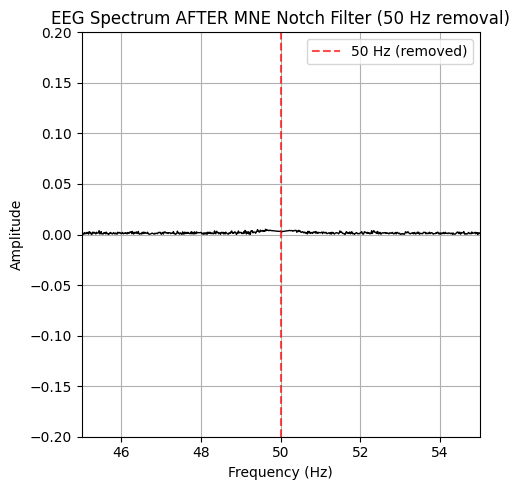

In [7]:
eyes_open_filtered = eyes_open.copy()
notch = 50.0

# Use the built-in notch filter MNE
eyes_open_filtered.notch_filter(freqs=np.arange(notch, sampling_rate / 2, notch), verbose=False)

oz_open_filtered = eyes_open_filtered["Oz"][0].flatten()

plt.figure(figsize=(5, 5))

rfft_result_filtered = fft.rfft(oz_open_filtered)
amplitude_spectrum_filtered = np.abs(rfft_result_filtered)
frequencies_filtered = fft.rfftfreq(len(oz_open_filtered), 1/sampling_rate)

plt.plot(frequencies_filtered, amplitude_spectrum_filtered, 'k-', linewidth=1)
plt.axvline(50, color='red', linestyle='--', alpha=0.7, label='50 Hz (removed)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('EEG Spectrum AFTER MNE Notch Filter (50 Hz removal)')
plt.grid(True)
plt.legend()
plt.xlim(45, 55)
plt.ylim(-0.2, 0.2)

plt.tight_layout()
plt.show()


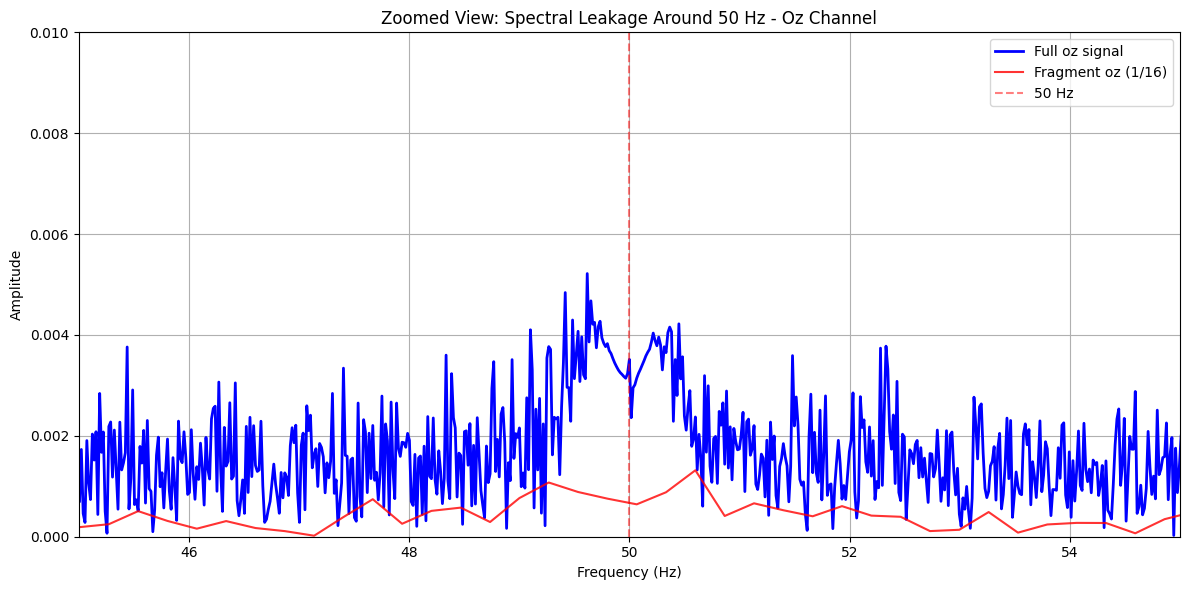

Длина полного сигнала oz: 60080 точек
Длина фрагмента oz (1/16): 3755 точек
Отношение длин: 16.0

Наблюдения:
1. У фрагмента хуже частотное разрешение (шире пики)
2. Видна спектральная утечка - энергия 'размазывается' по соседним частотам
3. Пик 50 Гц становится шире и менее четким


In [8]:
len_oz_open_filtered = len(oz_open_filtered)

# Calculate lennof small fragment (1/16 of the entire record)
fragment_length_oz = len_oz_open_filtered // 16
fragment_signal_oz = oz_open_filtered[:fragment_length_oz]  # first 1/16 of data

#calculate the spectra for full signal and fragment
rfft_full_oz = fft.rfft(oz_open_filtered)
amplitude_full_oz = np.abs(rfft_full_oz)
freq_full_oz = fft.rfftfreq(len(oz_open_filtered), 1/sampling_rate)

rfft_fragment_oz = fft.rfft(fragment_signal_oz)
amplitude_fragment_oz = np.abs(rfft_fragment_oz)
freq_fragment_oz = fft.rfftfreq(len(fragment_signal_oz), 1/sampling_rate)


plt.figure(figsize=(12, 6))

plt.plot(freq_full_oz, amplitude_full_oz, 'b-', linewidth=2, label='Full oz signal')
plt.plot(freq_fragment_oz, amplitude_fragment_oz, 'r-', linewidth=1.5, alpha=0.8, label='Fragment oz (1/16)')
plt.axvline(50, color='red', linestyle='--', alpha=0.5, label='50 Hz')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Zoomed View: Spectral Leakage Around 50 Hz - Oz Channel')
plt.grid(True)
plt.legend()
plt.xlim(45, 55)  

plt.ylim(0, 0.01) 
plt.tight_layout()
plt.show()

# Выводим информацию о длине сигналов
print(f"Длина полного сигнала oz: {len_oz_open_filtered} точек")
print(f"Длина фрагмента oz (1/16): {fragment_length_oz} точек")
print(f"Отношение длин: {len_oz_open_filtered / fragment_length_oz:.1f}")
print("\nНаблюдения:")
print("1. У фрагмента хуже частотное разрешение (шире пики)")
print("2. Видна спектральная утечка - энергия 'размазывается' по соседним частотам")
print("3. Пик 50 Гц становится шире и менее четким")

Зачем брали фрагмент 1/16?    
  Основная причина: Продемонстрировать спектральную утечку (spectral leakage)  
spectral leakage  
  Когда мы берем короткий отрезок сигнала, мы неявно умножаем его на прямоугольное окно. В частотной области это приводит к:
* Ухудшению частотного разрешения - пики становятся шире
* "Размазыванию" энергии - сигнал на одной частоте появляется и на соседних

Почему именно 1/16: Достаточно маленький, чтобы показать эффект   Достаточно большой, чтобы еще видеть пик 50 Гц

ЧТО МЫ СДЕЛАЛИ:
* Взяли полный EEG сигнал и маленький кусочек (1/16)
* Сделали Фурье-анализ обоих
* Сравнили их спектры вокруг 50 Гц

ДЛЯ ЧЕГО:  
Чтобы показать спектральную утечку - когда берем слишком короткий сигнал:
* Полный сигнал → четкий узкий пик на 50 Гц ✅
* Короткий фрагмент → размытый широкий пик ❌

ВЫВОД: Чем короче запись → тем хуже видим частоты → энергия "размазывается"    
!  Это объясняет почему для точного EEG анализа нужны длинные записи

Что мы увидим:
* Полный сигнал: четкий узкий пик на 50 Гц
* Фрагмент 1/16: широкий размытый пик, энергия "утекла" на соседние частоты

Практическое значение:
* Объясняет, почему для точного спектрального анализа нужны длинные записи
* Показывает важность выбора длины окна в обработке сигналов
* Демонстрирует компромисс между временным и частотным разрешением

Это фундаментальное понятие в цифровой обработке сигналов!

--------------------
=========================

Ожидаемая разница в спектральном содержании  
* Глаза закрыты:  
      Должна наблюдаться выраженная альфа-активность (8-13 Гц), особенно в затылочных областях мозга.    
      Уменьшение мощности в бета-диапазоне (13-30 Гц)    
      Наиболее выраженные изменения в канале Oz (затылочный)    
      Это классический феномен - когда глаза закрыты, зрительная кора "расслабляется" и генерирует синхронные альфа-волны.    
* Глаза открыты:  
      Альфа-активность значительно подавлена, поскольку зрительная система активно обрабатывает визуальную информацию.  
      Могут преобладать бета-волны (13-30 Гц).    



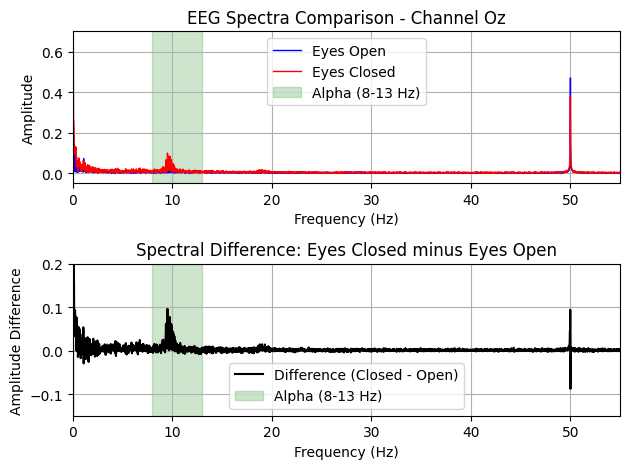

АНАЛИЗ АЛЬФА-РИТМА (8-13 Гц):
Средняя амплитуда Eyes Open: 0.005268
Средняя амплитуда Eyes Closed: 0.013960
Абсолютная разница: 0.008691
Относительное увеличение: 165.0%
  Разница: 0.008691 (165.0% увеличение)


In [9]:
oz_open_signal = eyes_open["Oz"][0].flatten()
oz_closed_signal = eyes_closed["Oz"][0].flatten()

sampling_rate = eyes_open.info['sfreq']

rfft_open = fft.rfft(oz_open_signal)
amplitude_open = np.abs(rfft_open)
freq_open = fft.rfftfreq(len(oz_open_signal), 1/sampling_rate)

rfft_closed = fft.rfft(oz_closed_signal)
amplitude_closed = np.abs(rfft_closed)
freq_closed = fft.rfftfreq(len(oz_closed_signal), 1/sampling_rate)


# the spectra represent the amplitude of the signal at different frequencies
plt.subplot(2, 1, 1)
plt.plot(freq_open, amplitude_open, 'b-', linewidth=1, label='Eyes Open')
plt.plot(freq_closed, amplitude_closed, 'r-', linewidth=1, label='Eyes Closed')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('EEG Spectra Comparison - Channel Oz')
plt.grid(True)
plt.xlim(0, 55)
plt.ylim(-0.05, 0.7)
plt.axvspan(8, 13, alpha=0.2, color='green', label='Alpha (8-13 Hz)')
plt.legend()


#the difference between the conditions (closed minus open)
plt.subplot(2, 1, 2)

difference = amplitude_closed - amplitude_open

plt.plot(freq_open, difference, 'k-', linewidth=1.5, label='Difference (Closed - Open)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude Difference')
plt.title('Spectral Difference: Eyes Closed minus Eyes Open')
plt.grid(True)
plt.xlim(0, 55)
plt.ylim(-0.15, 0.2)
plt.axvspan(8, 13, alpha=0.2, color='green', label='Alpha (8-13 Hz)')
plt.legend()

plt.tight_layout()
plt.show()

alpha_mask = (freq_open >= 8) & (freq_open <= 13)
# Анализ альфа-мощности
alpha_power_open = np.mean(amplitude_open[alpha_mask])
alpha_power_closed = np.mean(amplitude_closed[alpha_mask])

print("АНАЛИЗ АЛЬФА-РИТМА (8-13 Гц):")
print(f"Средняя амплитуда Eyes Open: {alpha_power_open:.6f}")
print(f"Средняя амплитуда Eyes Closed: {alpha_power_closed:.6f}")
print(f"Абсолютная разница: {alpha_power_closed - alpha_power_open:.6f}")
print(f"Относительное увеличение: {((alpha_power_closed/alpha_power_open)-1)*100:.1f}%")

print(f"  Разница: {alpha_power_closed - alpha_power_open:.6f} ({((alpha_power_closed/alpha_power_open)-1)*100:.1f}% увеличение)")

ПЕРВЫЙ ГРАФИК (сверху):  сами спектры - амплитуду сигнала на разных частотах
* Синяя линия: спектр при открытых глазах
* Красная линия: спектр при закрытых глазах
* Зеленая область: альфа-диапазон (8-13 Гц) - где ожидаем наибольшие изменения (акивен когда закрыты)

ВТОРОЙ ГРАФИК (снизу): разницу между условиями (закрытые минус открытые)
* Положительные значения: где мощность ВЫШЕ при закрытых глазах
* Отрицательные значения: где мощность НИЖЕ при закрытых глазах =где мощность ВЫШЕ при открытых глазах


Что такое спектрограмма?
* Обычный спектр (который мы строили) показывает: "Какие частоты ЕСТЬ в сигнале ВООБЩЕ"
* Спектрограмма показывает: "Какие частоты были в КАЖДЫЙ МОМЕНТ ВРЕМЕНИ"


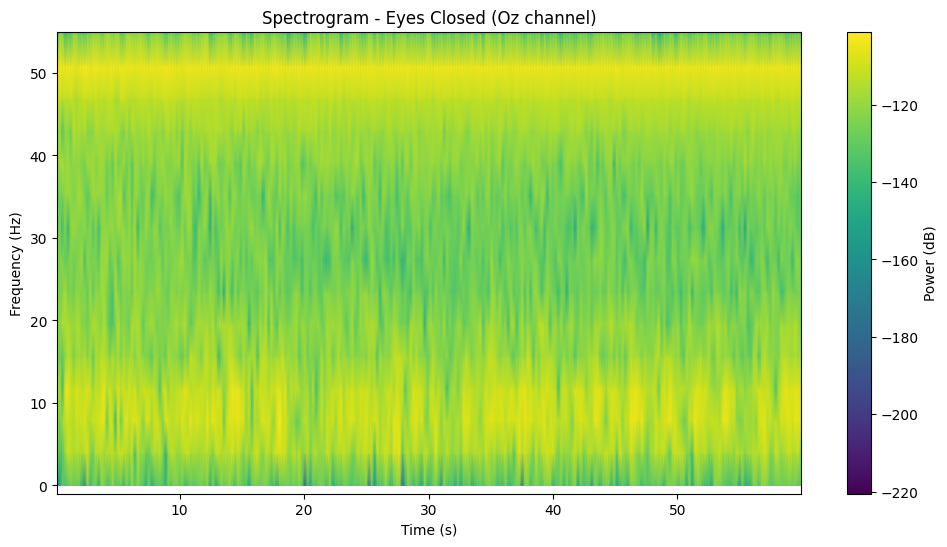

In [10]:
frequencies, times, Sxx = spectrogram(oz_closed_signal, fs=sampling_rate, nperseg=256)

# Визуализируем спектрограмму
plt.figure(figsize=(12, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.colorbar(label='Power (dB)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Spectrogram - Eyes Closed (Oz channel)')
plt.ylim(-1, 55) # Смотрим только на основные EEG частоты
plt.show()

* По вертикали - частоты (как в обычном спектре)
* По горизонтали - время
* Цвет - мощность (ярче = сильнее сигнал)
* Увидим как альфа-ритм (8-13 Гц) меняется во времени

1. АЛЬФА-РИТМ (8-13 Гц)
* Видна как яркая горизонтальная полоса в диапазоне ~8-12 Гц
* Мощность альфа-ритма не постоянна - она меняется\пульсирует во времени. Есть моменты когда альфа-ритм сильнее (ярче) и слабее (темнее)

2. ВРЕМЕННАЯ ДИНАМИКА
* Альфа-ритм проявляется всплесками (bursts), а не постоянно
* Видны альфа-спиндлы - короткие усиления альфа-активности
* Мощность ритма осциллирует во времени (волнообразна)

Это объясняет почему в обычном спектре мы видели 'усредненную' картину.  
Спектрограмма показывает, что мозговая активность - это динамический процесс, а не статическая картина!  

# (optional) Exercise 7: Other time-frequency analysis methods:
There are other methods to compute a frequency spectrum or a time-frequency representation, such as:
* [Wavelets on Wikipedia](https://en.wikipedia.org/wiki/Wavelet),
* [Morlet wavelets on Mike Cohen's YouTube channel](https://youtu.be/7ahrcB5HL0k),
* [Auto regressive models on Wikipedia](https://en.wikipedia.org/wiki/Autoregressive_model).

*These are recommended to know about, but **not required materials**.*

1. Reproduce the analysis of Exercise 6., but use the other methods presented above instead of the Fast Fourier Transform.   

# Exercise 8: Spectral Filters

[Spectral filters](https://atmos.washington.edu/~breth/classes/AM582/lect/lect12-notes.pdf) can be used to discard spectral data that we're not interested in (e.g. that nasty 50Hz powerline noise). They work by filtering out the spectral power at a certain chosen frequency range while retaining all the information outside of that range. A high-pass filter retains higher frequencies (lets them through/lets them *pass*), while a low-pass filter does the opposite. A band-pass filter removes all frequencies outside a specified band and a band-stop filter removes only the frequencies inside the stop-band. The stop-band filter is also called a Notch filter when the stop band is relatively narrow; for example: the range [48Hz - 52Hz] surrounding the 50Hz powerline noise.

Spectral filters are first *designed* according to the sampling rate of the data they will be applied on and the response curve we want from that filter. The response curve describes how well the filter preserves frequencies inside the desired band and how well it removes frequencies outside the desired band. There are multiple filter types, but the [Butterworth filter](https://en.wikipedia.org/wiki/Butterworth_filter) is the most commonly used one, as it has a maximally flat (i.e has no ripples, see picture) response curve in the passband and rolls off towards zero in the stopband. 

<img src="data/ripple.png" width="450" align="center" alt="Different filter types, showcasing the ripple effect"/>

[Source](https://en.wikipedia.org/wiki/Butterworth_filter)

Finally, filters have an important property called *order*. In short: the higher the order the closer you get to the ideal "Brick wall" (i.e. square wave) response curve, where a filter would perfectly remove the power of all frequencies outside the desired band and keep all frequencies in the desired band unchanged. Of course, this does not come without a cost - higher order filters are more computationally heavy (in software this requires more processing power, in hardware - more physical components) and are prone to becoming unstable. The figure below demonstrates how the response of the Butterworth filter changes with order.

<img src="data/butter.png" width="450" align="center" alt="Filter response"/>

[Source](https://www.electronics-tutorials.ws/filter/filter_8.html)

We've provided an example where we create sinusoids with frequencies from 5 to 100 Hz, after which we filter out the ones above 16 Hz. 
1. Do the same for the EEG signal (e.g. open condition). Note that such filtering will also take out the 50 Hz powerline noise.Experiment with different filter orders and stopband/passband sizes. **Tip:** plot the frequency spectrum before and after applying the spectral filter.

It is important to note that spectral filters are not a magical tool that instantly work perfectly. Spectral filters always have a 'warm-up' period, where they need to observe some data before they kick in and start removing frequencies properly. This is relevant to us, as BCI experts, as we often like to slice our data into epochs. If we were to apply the filter on every tiny epoch, then we will experience this warm-up behaviour on every single epoch. This is why you should preferably filter your data before slicing it into epochs or alternatively apply zero-padding/grabbing more data than neccessary for each epoch, such that your filter can warm up on data you can discard.

Finally, an import note here. So far we have come across two different filtering methods: spatial ones and spectral (i.e., frequency) ones. Make sure you understand the differences between these two, what they are used for, and how they work!

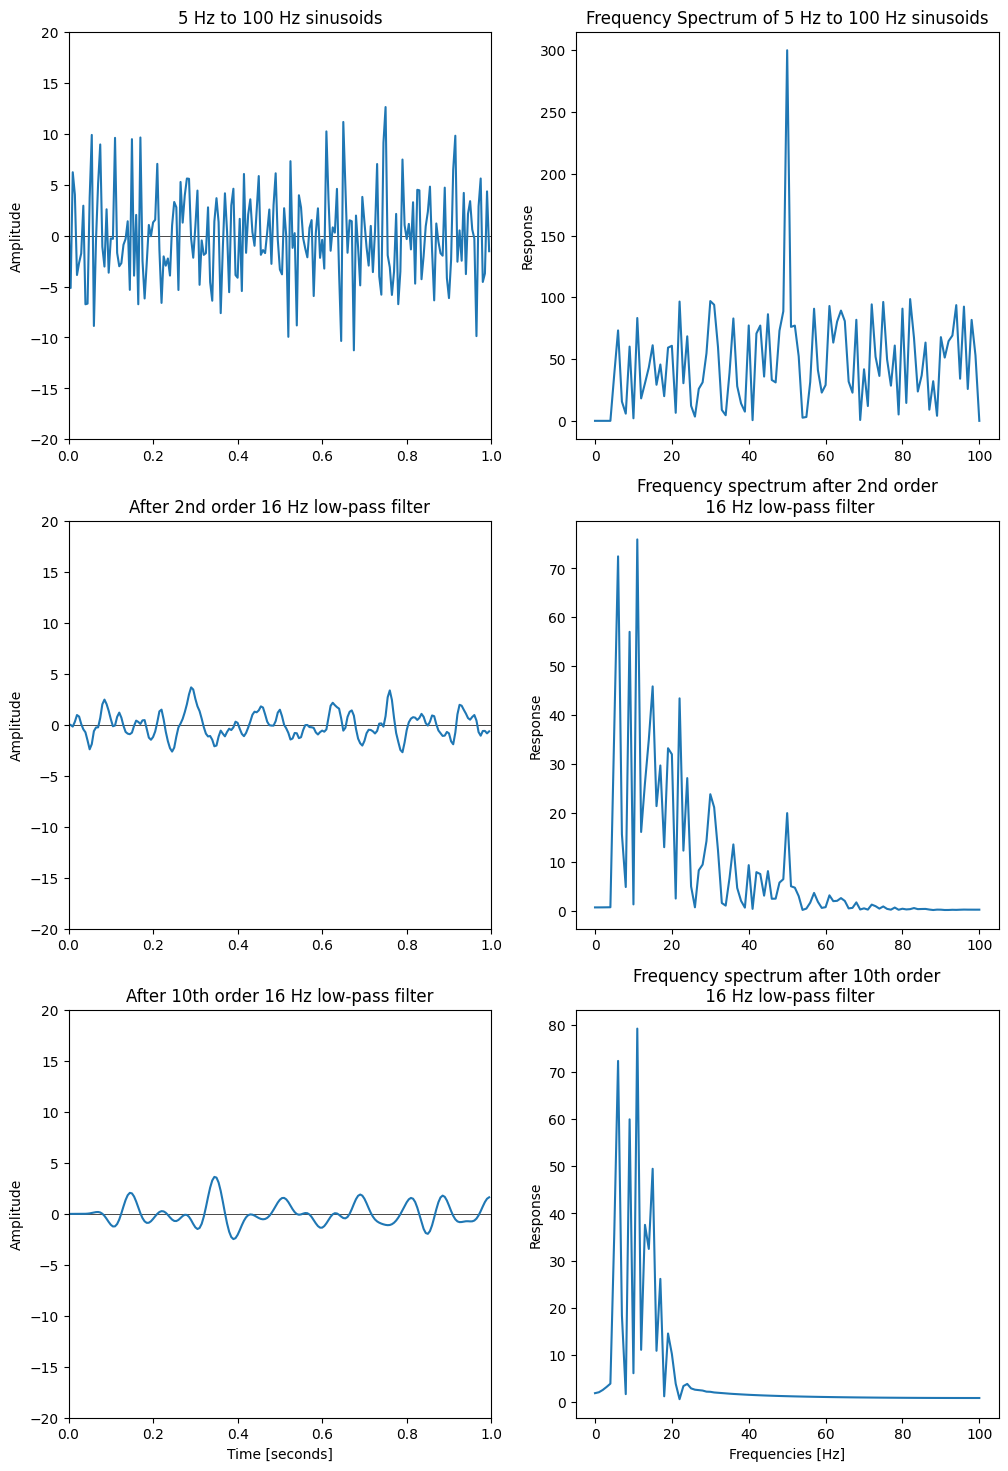

In [11]:
# Example
#Создает "микшер" из разных звуков (от 5 до 100 Гц), а потом показывает, как фильтр убирает высокие звуки.

example_duration = 1.0        # Запись длится 1 секунду  #Готовим "микрофон", который будет записывать 1 секунду, делая 200 замеров в секунду.
example_fs = 200.0            # Частота записи: 200 раз в секунду
example_N_samples = int(example_fs*example_duration)  # Всего точек: 200
example_time = np.arange(example_N_samples) / example_fs  # Временная шкала от 0 до 1 сек

#Создание микшера из звуков
# Create dummy signal with sinusoids from 5 to 100 Hz                  
example_signal = np.zeros(example_N_samples)  # Начинаем с тишины
for freq in range(5,100):                     # Для каждой частоты от 5 до 99 Гц   Берем 95 разных звуков (от 5 Гц до 99 Гц)
    amp_coef = np.random.rand()               # Случайная громкость                Каждому даем случайную громкость
    if freq==50:
        # amplify the 50Hz component to simulate a powerline noise
        amp_coef = 3  # Делаем звук 50 Гц в 3 раза громче (имитация помехи)        Звук 50 Гц делаем ОЧЕНЬ громким (как шум от розетки)
     # randomly amplify a randomly phase-shifted sinusoid
    # Добавляем этот звук к общему микшеру
    example_signal += amp_coef * np.sin(2*np.pi*freq*example_time + np.random.rand()*2*np.pi)    #Всё это смешиваем в один сложный сигнал

    
fig, ax = plt.subplots(3, 2, figsize=(12,18))

# Левый график - как сигнал выглядит во времени   Видим "кашу" из волн - это все 95 звуков одновременно
ax[0][0].plot(example_time, example_signal)
ax[0][0].axis([0, 1, -20, 20])
ax[0][0].axhline(0,0,1, c='k',linewidth=0.5,zorder=0)
ax[0][0].set_title('5 Hz to 100 Hz sinusoids')
ax[0][0].set_ylabel('Amplitude')
# Правый график - частотный спектр (какие частоты есть и насколько громкие)   Видим "гребенку" - каждый зубец это отдельная частота. Зубец на 50 Гц самый высокий!
ax[0][1].plot(fft.rfftfreq(example_N_samples,1/example_fs), abs(fft.rfft(example_signal)))
ax[0][1].set_title('Frequency Spectrum of 5 Hz to 100 Hz sinusoids')
ax[0][1].set_ylabel('Response')

# Apply Butterworth Low-pass Filter of 2nd order
# Делаем "сито", которое пропускает только низкие звуки (до 16 Гц). Порядок 2 - это "мягкое" сито
sos2 = butter(2, 16, 'lp', fs=example_fs, output='sos') # Создаем фильтр
filtered2 = sosfilt(sos2, example_signal)  # Пропускаем сигнал через фильтр

# Слева: Видим более плавную волну (остались только низкие частоты)
ax[1][0].plot(example_time, filtered2)
ax[1][0].axhline(0,0,1, c='k',linewidth=0.5 ,zorder=0)
ax[1][0].axis([0, 1, -20, 20])
ax[1][0].set_title('After 2nd order 16 Hz low-pass filter')
ax[1][0].set_ylabel('Amplitude')
#Справа: На спектре остались только частоты до ~16 Гц, но переход плавный
ax[1][1].plot(fft.rfftfreq(example_N_samples,1/example_fs), abs(fft.rfft(filtered2)))
ax[1][1].set_title('Frequency spectrum after 2nd order\n 16 Hz low-pass filter')
ax[1][1].set_ylabel('Response')

# Apply Butterworth Low-pass Filter of 10th order
# Делаем "супер-сито" (порядок 10), которое ОЧЕНЬ резко обрезает всё выше 16 Гц.
sos10 = butter(10, 16, 'lp', fs=example_fs, output='sos')
filtered10 = sosfilt(sos10, example_signal)

#Слева: Волна стала еще более плавной
ax[2][0].plot(example_time, filtered10)
ax[2][0].axhline(0,0,1, c='k',linewidth=0.5 ,zorder=0)
ax[2][0].axis([0, 1, -20, 20])
ax[2][0].set_title('After 10th order 16 Hz low-pass filter')
ax[2][0].set_xlabel('Time [seconds]')
ax[2][0].set_ylabel('Amplitude')
#Справа: На спектре видна почти вертикальная граница на 16 Гц!
ax[2][1].plot(fft.rfftfreq(example_N_samples,1/example_fs), abs(fft.rfft(filtered10)))
ax[2][1].set_title('Frequency spectrum after 10th order\n 16 Hz low-pass filter')
ax[2][1].set_xlabel('Frequencies [Hz]')
ax[2][1].set_ylabel('Response')

plt.show()

Верхний ряд: Был микшер из ВСЕХ звуков (5-100 Гц)
Средний ряд: После "мягкого" фильтра (порядок 2) - остались низкие звуки, но не идеально
Нижний ряд: После "крутого" фильтра (порядок 10) - остались ТОЛЬКО низкие звуки, обрезка четкая

Важно: Оба фильтра убрали противный громкий звук на 50 Гц!

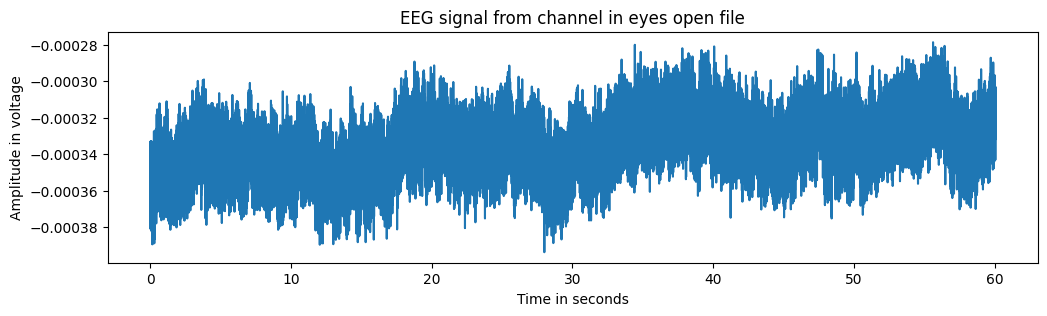

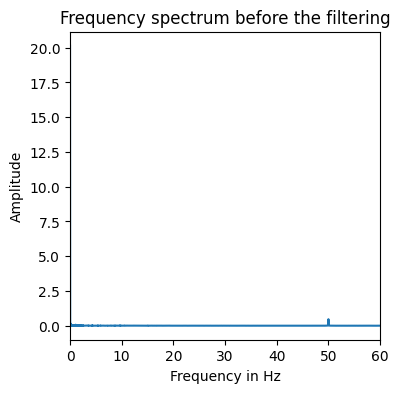

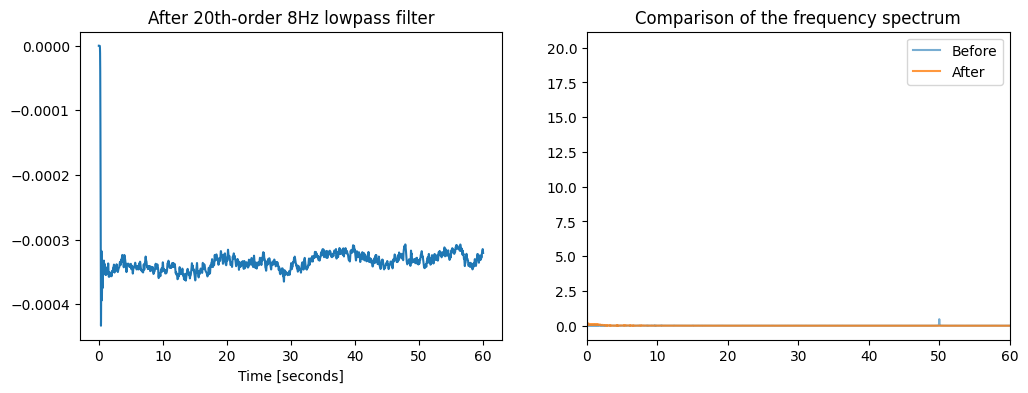

In [12]:
# Answer here
channel = "Oz"  # Выбрали электрод на затылке
fs = int(eyes_open.info["sfreq"])  # Узнали частоту записи (например 250 Гц)
sig = eyes_open.copy().pick_channels([channel]).get_data().squeeze()  #достаем сигнал только с одного датчика, убираем лишние размерности
t = np.arange(len(sig)) / fs  #  создаем шкалу времени в секундах

# Смотрим как выглядит мозговая активность во времени - видим эти характерные "дрожания".
plt.figure(figsize=(12,3)) #Характерные всплески, ритмы, артефакты
plt.plot(t, sig)
plt.title("EEG signal from channel in eyes open file")
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude in voltage")
plt.show()

freqs = fft.rfftfreq(len(sig), 1/fs)  # Шкала частот
spectrum = np.abs(fft.rfft(sig))      # Мощность на каждой частоте

#Смотрим какие частоты есть в сигнале. Должен быть виден пик на 50 Гц - это та самая помеха от розетки!
plt.figure(figsize=(4,4))
plt.plot(freqs, spectrum)
plt.title("Frequency spectrum before the filtering")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.xlim(0,60)  # Смотрим только до 60 Гц
plt.show()

#Создали супер-мощный фильтр, который оставляет только очень низкие частоты (до 8 Гц).
order = 20       # ОЧЕНЬ высокий порядок!Почти вертикальная стенка     #Проблема: Высокие порядки создают артефакты!
cutoff = 8       # Отсечка на 8 Гц   #Проблема: Высокие порядки создают артефакты!
sos = butter(order, cutoff, 'lp', fs=fs, output='sos')  #    low-pass = "низкочастотный" - пропускает низкие частоты  #Создаем супер-мощное сито, которое оставляет только медленные волны мозга"
filtered = sosfilt(sos, sig)  # Пропускаем сигнал через фильтр  # Каждая точка сигнала математически пересчитывается так, чтобы высокие частоты исчезли.

filtered_spectrum = np.abs(fft.rfft(filtered))

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(t, filtered)
ax[0].set_title(f"After {order}th-order {cutoff}Hz lowpass filter")
ax[0].set_xlabel("Time [seconds]")
ax[1].plot(freqs, spectrum, label="Before", alpha=0.6)
ax[1].plot(freqs, filtered_spectrum, label='After', alpha=0.8)
ax[1].set_xlim(0, 60)
ax[1].set_title("Comparison of the frequency spectrum")
ax[1].legend()
plt.show()

📈 ЛЕВЫЙ ГРАФИК (время):
* Стало более ПЛАВНЫМ - ушли высокочастотные дрожания
* Сохранились медленные волны - дельта, тета, альфа ритмы
* Исчезли быстрые колебания - бета, гамма ритмы

📊 ПРАВЫЙ ГРАФИК (спектр):
*  ДО фильтра: Полный спектр, виден пик 50 Гц
* ПОСЛЕ фильтра:
    * ВСЕ частоты выше 8 Гц должны быть почти на НУЛЕ
    * Пик 50 Гц ДОЛЖЕН ИСЧЕЗНУТЬ полностью! ✅
    * Остались только частоты 0-8 Гц

ЧЕГО ДОЛЖЕН ДОСТИЧЬ ФИЛЬТР:
*  Убрать помеху 50 Гц от электрической сети
*  Сохранить полезные ритмы мозга (альфа до 13 Гц)
*  Не исказить сигнал (проблема при order=20!)
  
Совет: Попробуй order = 4 и cutoff = 16 для более безопасной фильтрации! 🚀

# Exercise 9: Hilbert Transform

Event-related potentials (ERPs) are phase-locked signals, meaning we know when to expect peaks in the signal (after stimulus onset), which allows us to average over multiple epochs to get a better estimation of an ERP's shape. Neural oscilations, on the other hand, are phenomena that are typically not phase locked. This means that we can't average them directly, as they might be in antiphase (negative peaks of one epoch coincide with positive peaks of another), resulting in an uninformative sum close to 0 (because they cancel each other out). For oscillations, instead of averaging in the time-domain to obtain ERPs, one would instead average in the frequency-domain to obtain event-releated spectral pertubations (ERsP). 

1. Explain in you own words how averaging helps removing noise in the time-domain to extract ERPs, and how it helps to clean-up noise in the frequency-domain to extract ERsPs.

Another way of working with (single-trial, non-averaged) oscillations is by looking at the [envelope](https://en.wikipedia.org/wiki/Envelope_(waves)) of a signal, instead of the signal itself. We can calculate the envelope using the [Hilbert transform](https://www.gaussianwaves.com/2017/04/extract-envelope-instantaneous-phase-frequency-hilbert-transform/). We recommend this [video](https://youtu.be/jy7IxIXUAJk) for a deeper understanding of the Hilbert transform.

2. Use the `hilbert` function provided by the `scipy.signal` library in order to calculate the envelope of the toy signal below and plot the signal together with its envelope.

## ERP vs ERsP - кратко и понятно

 🎯 **ERP (Event-Related Potential)**
- **Что:** Медленные потенциалы мозга, ВПРЫСК напряжения
- **Когда:** Строго после стимула (через 100-500 мс)
- **Как анализируем:** Усредняем СЫРЫЕ сигналы
- **Результат:** Видим "форму волны" - пики и впадины

*Пример: P300 - позитивный пик через 300 мс после редкого стимула*

 📊 **ERsP (Event-Related Spectral Perturbation)**
- **Что:** Изменение СИЛЫ ритмов мозга (альфа, бета, тета...)
- **Когда:** Может быть до/после/во время стимула
- **Как анализируем:** Усредняем СПЕКТРЫ частот
- **Результат:** Видим "горячие зоны" - какие частоты усилились/ослабли

*Пример: Подавление альфа-ритма (8-13 Гц) при открытии глаз*

 ⚡ **Главные отличия**

| ERP | ERsP |
|-----|------|
| Фазо-синхронизированные сигналы | Несинхронизированные осцилляции |
| Временная область | Частотная область |
| "Форма волны" | "Сила ритмов" |
| Четко привязан к стимулу | Может быть до стимула |
| Усредняем сигналы | Усредняем спектры |

**Проще:** 
- **ERP** - "молния" после стимула ⚡
- **ERsP** - "изменение громкости музыки" мозга 🎵

## Объяснение усреднения для ERP и ERsP

🎯 Усреднение во временной области (для ERP)

**Аналогия:** Представьте, что вы пытаетесь расслышать чьи-то слова в шумной комнате.

- **Полезный сигнал (ERP):** Всегда повторяется одинаково после стимула
- **Шум:** Случайные флуктуации, разные в каждой пробе

**Как работает усреднение:**
- Складываем много одинаковых отрезков ЭЭГ после стимулов
- Случайный шум в разных пробах **компенсируется** (+ и -)
- Постоянный ERP **усиливается** с каждой новой пробой

**Результат:** Шум уменьшается, четкий ERP становится видимым

📊 Усреднение в частотной области (для ERsP)

**Аналогия:** Как найти популярную радиостанцию среди помех.

- Переводим каждый отрезок ЭЭГ в **спектр** (какие частоты присутствуют)
- Смотрим изменения мощности в конкретных частотных диапазонах

**Как работает усреднение:**
- Вычисляем спектр для каждой эпохи
- Усредняем спектры по многим пробам
- Случайные спектральные всплески шума **сглаживаются**
- Устойчивые изменения в определенных частотах **проявляются**

**Результат:** Видим, какие частоты усиливаются/ослабевают после стимула

💡 Ключевое отличие

- **ERP:** Усредняем СЫРЫЕ сигналы → видим форму волны
- **ERsP:** Усредняем СПЕКТРЫ → видим изменения мощности частот

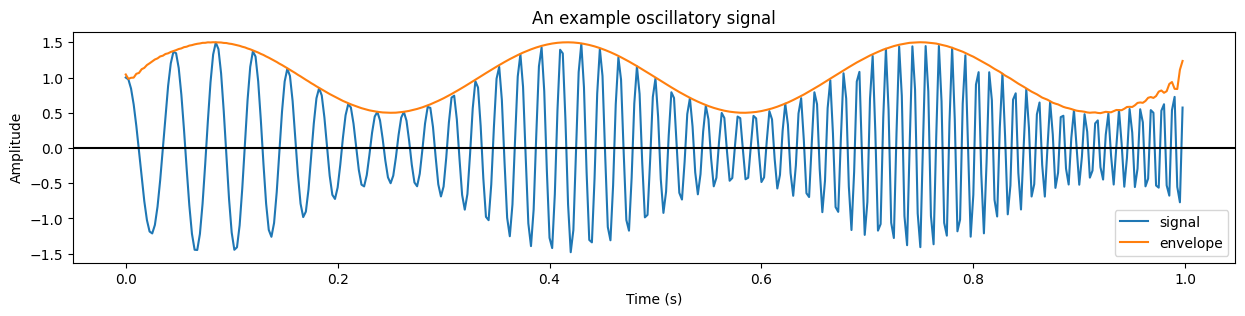

In [18]:
#Создает сложный колебательный сигнал для тестирования преобразования Гильберта
duration = 1.0 # Длительность сигнала: 1 секунда
fs = 400.0   # Частота дискретизации: 400 Гц (400 замеров в секунду)
samples = int(fs*duration) # Всего точек: 400
t = np.arange(samples) / fs   # Временная шкала от 0 до 1 сек

# Generate a sinusoid that starts at 20hz and increases to 100hz over 1 second
signal = chirp(t, 20.0, t[-1], 100.0) #Сигнал, который начинается на 20 Гц и плавно увеличивается до 100 Гц за 1 секунду

# Some amplitude modulation to get an envelope that isn't just a straight line
signal *= (1.0 + 0.5 * np.sin(2.0*np.pi*3.0*t) )   # Меняем "громкость" сигнала с частотой 3 Гц  - Сигнал то усиливается, то ослабевает 3 раза в секунду

#ex2-------------------------------
# Computing the envelope
hilbert_signal = hilbert(signal) # Получаем аналитический( комплексный) сигнал    Возвращает real_part + j*imag_part   Мнимая часть =оригсигнал, сдвинутый по фазе на 90°
envelope = np.abs(hilbert_signal) #  Огибающая ( плавная кривая, обводящая пики)= модуль комплексного сигнала  |a + jb| = √(a² + b²)
# Чтобы получить ПОЛНУЮ ИНФОРМАЦИЮ о сигнале:
#Только положение → знаем где маятник, но не знаем куда движется + Скорость → знаем и где, и куда, и с какой сило
# огибающая = √(положение² + скорость²)
#Без сдвига → можем только смотреть на сигнал
#Со сдвигом → можем измерить его СИЛУ в каждый момент
#    Чтобы измерить длину наклонной палки, нужны 2 перпендикулярных измерения (высота и ширина)  --Сдвиг на 90° дает это второе перпендикулярное измерение
#------------------------------------
# Visualize
plt.figure(figsize=(15, 3))
plt.plot(t, signal, label = "signal")
plt.plot(t, envelope, label = "envelope") #
plt.axhline(0, c='k')
plt.ylabel('Amplitude')
plt.xlabel('Time (s)')
plt.title('An example oscillatory signal')
plt.legend()

#Показываем получившийся сложный сигнал:
 #   Быстрые колебания (20→100 Гц)
 #   Медленные изменения амплитуды (3 Гц)

#📈 Что увидим на графике:
  #  Частота плавно увеличивается слева направо
  #  Амплитуда медленно "пульсирует" 3 раза за секунду
  #  Идеальный сигнал для демонстрации огибающей!
     #  Синяя линия: Быстрые колебания (чирп-сигнал)
     # Красная линия: Плавная огибающая, которая обводит все пики
     # Огибающая будет повторять форму амплитудной модуляции (3 Гц)

# Exercise 10: Further remarks on preprocessing and MNE

Throughout this assignment you have learned about important concepts from signal analysis and how they are used for preprocessing and feature extraction in BCIs. This was not at all an exhasutive list. Typical propreccising steps involve:
- Re-referencing: common-average-referencing (CAR), Laplacian, mastoid referencing, etc. (note, kind of non-learned spatial filter)
- Detrending (note, detrending is also achieved by applying a high-pass filter)
- Spectral filter: low-pass, high-pass, band-pass, band-stop (notch)
- Resampling: e.g. downsampling the data to a lower sampling frequency
- Data cleaning: e.g., removing eye blinks with ICA
- Outlier removal: e.g., removing channels/trials/epochs
- Baselining: removing means (of a baseline period) from individual epochs

Throughout this assignment you have been using numpy and scipy functionality to preprocess and analyse the data. These routines are typically easy to work with. However, MNE provides functionality for preprocessing routines as well as many analysis methods. These make analysing BCI data even easier! 

1. Inspect the code snippet below that uses some MNE tools.
2. Make a list of (examples of) MNE functions that implement the steps listed above.

📋 Что такое предобработка данных ЭЭГ? Это как "помыть и почистить" сырые данные мозга перед анализом, чтобы убрать всё лишнее.  
🧹 Основные шаги очистки:
1) Повторное референцирование - выбрать "точку отсчета" для всех датчиков  
      Как выбрать, откуда измерять высоту горы
1) Удаление тренда - убрать медленные изменения (например, от усталости)  
      Как убрать общий наклон с фотографии
1) Спектральная фильтрация - убрать ненужные частоты (помехи, шумы)  
      Как настроить эквалайзер - убрать басы или верхние частоты
1) Передискретизация - уменьшить частоту записи (если слишком высокая)  
      Как уменьшить качество фото чтобы она занимала меньше места
1)  Очистка данных - убрать артефакты (моргания, движения)  
     Как убрать красные глаза с фотографии
1) Удаление выбросов - убрать испорченные участки записи  
      Как выкинуть испорченные кадры из видео
1) Базовое выравнивание - вычесть фоновую активность  
      Как измерить рост человека относительно уровня пола

🛠️ Про MNE:
* Раньше: Вы использовали numpy/scipy - это как инструменты "сделай сам"
* Теперь: MNE - это готовые профессиональные инструменты "в одном флаконе"
  
📝 Что нужно сделать:
* Посмотреть на пример кода с MNE
*  Найти какие функции MNE соответствуют каждому из 7 шагов очистки
* Понять, как MNE упрощает работу с данными ЭЭГ
  
По сути: Учимся использовать "профессиональный набор инструментов" вместо "самодельных"! 🔧


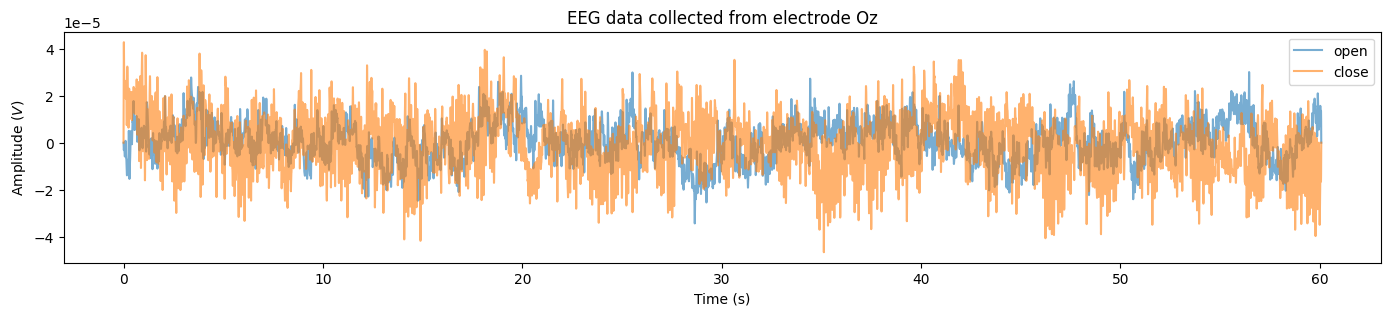

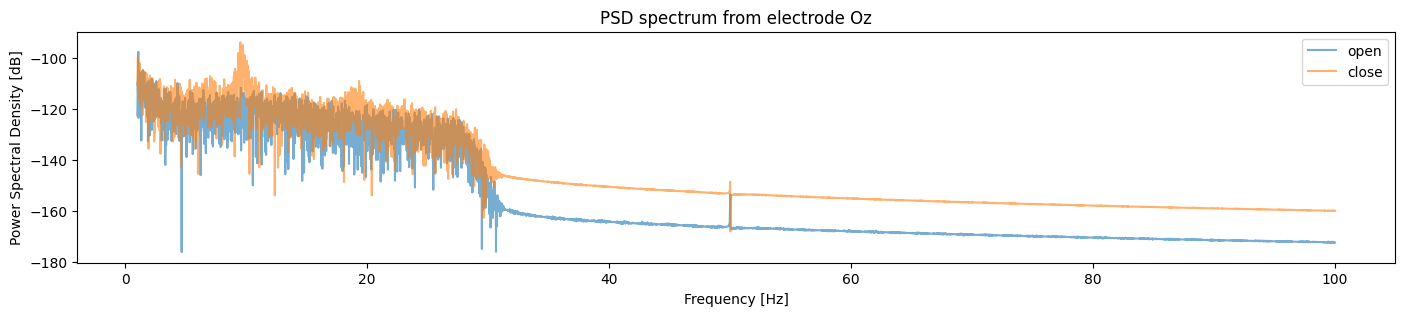

In [15]:
#Сравнивает ЭЭГ-сигналы при открытых и закрытых глазах на электроде Oz (затылок)

# Apply a band-pass
_eyes_open = eyes_open.filter(l_freq=0.1, h_freq=25, verbose=False)
_eyes_closed = eyes_closed.filter(l_freq=0.1, h_freq=25, verbose=False)
        #l_freq=0.1 - оставляем частоты ОТ 0.1 Гц (убираем сверхмедленные дрейфы)
            #h_freq=25 - оставляем частоты ДО 25 Гц (убираем высокочастотные шумы)
    #Результат: Полосовой фильтр 0.1-25 Гц --- Альфа-ритм (8-13 Гц) - главный герой сравнения  +Тета/бета - дополнительные ритмы

# Visualize the first epoch of both conditions
plt.figure(figsize=(17, 3))
plt.plot(_eyes_open.times, _eyes_open['Oz'][0].flatten(), label='open', alpha=0.6)
plt.plot(_eyes_closed.times , _eyes_closed['Oz'][0].flatten(), label='close', alpha=0.6)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude ($V$)')
plt.title('EEG data collected from electrode Oz')

# Compute PSD
tmin = 0.
tmax = 60.
fmin = 1.
fmax = 100.

 #КАКИЕ ЧАСТОТЫ есть в сигнале и НАСКОЛЬКО ОНИ СИЛЬНЫ
    #Welch method - усреднение спектров для лучшего качества
       # min=1., fmax=100. частоты от 1 до 100 Гц     ----n_fft - размер окна для анализа       ---window='boxcar' - тип окна (прямоугольное)
psds_open, freqs_open = mne.time_frequency.psd_array_welch(_eyes_open["Oz"][0], sfreq=_eyes_open.info['sfreq'],
    n_fft=int(_eyes_open.info['sfreq'] * (tmax - tmin)), fmin=fmin, fmax=fmax, window='boxcar', verbose=False)
psds_close, freqs_close = mne.time_frequency.psd_array_welch(_eyes_closed["Oz"][0], sfreq=_eyes_closed.info['sfreq'],
    n_fft=int(_eyes_closed.info['sfreq'] * (tmax - tmin)), fmin=fmin, fmax=fmax, window='boxcar', verbose=False)

# Visualize PSD
plt.figure(figsize=(17, 3))
plt.plot(freqs_open, 10 * np.log10(psds_open.flatten()), label="open", alpha=0.6) #10 * np.log10(psds_open) - переводим в децибелы (dB)
plt.plot(freqs_close, 10 * np.log10(psds_close.flatten()), label="close", alpha=0.6) #Зачем: Человеческое зрение лучше видит различия в логарифмической шкале
plt.legend()
plt.title("PSD spectrum from electrode Oz")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density [dB]')
plt.show()

#Ожидаемый результат: При закрытых глазах - высокий пик в области 8-13 Гц (альфа-ритм)

🎯 ГЛАВНЫЕ MNE ФУНКЦИИ В КОДЕ:
1. Фильтрация
        raw.filter(l_freq, h_freq)  # Полосовой фильтр
3. Спектральный анализ      mne.time_frequency.psd_array_welch()  # Расчет PSD
4. Работа с даннымиraw['Oz'][0]          # Доступ к данным электрода Oz
raw.info['sfreq']     # Получение частоты дискретизации
raw.times            # Временная шкала

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here